In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [4]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [5]:
from utils.cart import make_wcs, to_cart

In [6]:
cmap = 'RdBu_r'

In [7]:
! nvidia-smi

Wed Mar 30 09:23:01 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.57.02    Driver Version: 470.57.02    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:06:00.0 Off |                    0 |
| N/A   35C    P0    25W / 250W |      0MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  Tesla V100-PCIE...  On   | 00000000:2F:00.0 Off |                    0 |
| N/A   

## Fermi data

In [7]:
from astropy.io import fits

In [8]:
counts_fits = fits.open("/n/holyscratch01/iaifi_lab/yitians/ccube_ultracleanveto_bestpsf_joined.fits")

In [9]:
pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 25
i_e = 40

In [10]:
upsample_factor = int(pixel_size_target / pixel_size_data)

In [11]:
counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

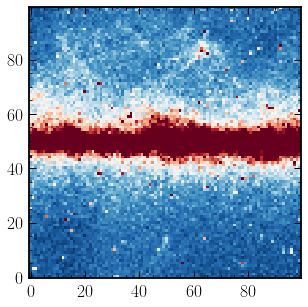

In [12]:
plt.imshow(counts_downsampled, vmax=100, cmap=cmap, origin='lower')

## Templates

In [23]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [24]:
pixelsize

0.5

In [25]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0


## Fit to real data

In [ ]:
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.distributions import constraints
from numpyro.infer import Predictive, SVI, Trace_ELBO, RenyiELBO
from numpyro.infer.autoguide import AutoIAFNormal, AutoMultivariateNormal, AutoDiagonalNormal, AutoLaplaceApproximation, AutoBNAFNormal
from jax.lax import scan
import jax.lax as lax

def model(data, rng_key=random.PRNGKey(13)):
    
    theta_gce = numpyro.sample("theta_gce", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_iso = numpyro.sample("theta_iso", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_bub = numpyro.sample("theta_bub", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_psc = numpyro.sample("theta_psc", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_pibrem = numpyro.sample("theta_pibrem", dist.Uniform(0., 40.), rng_key=rng_key)
    theta_ics = numpyro.sample("theta_ics", dist.Uniform(0., 20.), rng_key=rng_key)
    
    mu = temp_gce_cart * theta_gce + \
        temp_iso_cart * theta_iso + \
        temp_bub_cart * theta_bub + \
        temp_psc_cart * theta_psc + \
        temp_mO_pibrem_cart * theta_pibrem + \
        temp_mO_ics_cart * theta_ics
    
    
    data = data.reshape(-1, data.shape[-1] * data.shape[-2])
    mu = mu.reshape(-1, data.shape[-1] * data.shape[-2])
    
    with numpyro.plate("data_plate", data.shape[-1]):
        return numpyro.sample("obs", dist.Poisson(mu), obs=data, rng_key=rng_key)


/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/jax/experimental/optimizers.py:28: FutureWarning: jax.experimental.optimizers is deprecated, import jax.example_libraries.optimizers instead
  warnings.warn('jax.experimental.optimizers is deprecated, '
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/jax/experimental/stax.py:28: FutureWarning: jax.experimental.stax is deprecated, import jax.example_libraries.stax instead
  warnings.warn('jax.experimental.stax is deprecated, '


In [73]:
from numpyro.infer import MCMC, HMC, NUTS

kernel = NUTS(model, target_accept_prob=0.9)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=3200)
mcmc.run(rng_key=random.PRNGKey(0), data=counts_downsampled)

mcmc.print_summary()

sample: 100%|█| 4200/4200 [00:46<00:00, 90.53it/s, 15 steps of size 3.21e-01. acc. prob=



                    mean       std    median      5.0%     95.0%     n_eff     r_hat
     theta_bub      0.65      0.04      0.65      0.58      0.71   2647.21      1.00
     theta_gce      2.49      0.06      2.49      2.39      2.59   2555.06      1.00
     theta_ics      6.54      0.10      6.54      6.37      6.70   2333.48      1.00
     theta_iso      0.01      0.01      0.00      0.00      0.01   3595.91      1.00
  theta_pibrem     19.87      0.06     19.87     19.77     19.97   2714.45      1.00
     theta_psc      0.20      0.01      0.20      0.18      0.21   3009.03      1.00

Number of divergences: 0


## Sims

In [ ]:
mesh_dim = np.linspace(0, n_pixels, (n_pixels + 1) * upsample_factor)
interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_gce_cart)
temp_gce_cart_upsampled = interp(mesh_dim, mesh_dim)

In [ ]:
from models.scd import dnds

In [ ]:
n_sim = 30000

prior_ps = [[0.001, 10.0, 1.1, -10.0, 5.0, 1., 0.001, 10.0, 1.1, -10.0, 5.0, 1.], 
            [2., 20.0, 1.99, 1.99, 40.0, 4.99, 2., 20.0, 1.99, 1.99, 40.0, 4.99]]

prior_poiss = [[0.001, 0.001, 0.001, 0.001, 16.0, 6.0], 
               [2., 1.5, 1., 1., 21.0, 7.0]]

temps_ps = np.array([temp_gce_cart, temp_dsk_cart])
temps_poiss = np.array([temp_gce_cart, temp_iso_cart, temp_bub_cart, temp_psc_cart, temp_mO_pibrem_cart, temp_mO_ics_cart])

temps_ps_upsampled = []

for temp_ps in temps_ps:
    interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_ps)
    temp_ps_upsampled = interp(mesh_dim, mesh_dim)
    temps_ps_upsampled.append(temp_ps_upsampled)

thetas = np.random.uniform(low=prior_poiss[0] + prior_ps[0], high=prior_poiss[1] + prior_ps[1], size=(n_sim, len(prior_ps[0]) + len(prior_poiss[0])))

In [ ]:
from tqdm.notebook import tqdm

In [116]:
s_ary = np.logspace(-1, 2, 1000)
logs_ary = np.log10(s_ary)
dlogs_ary = np.diff(logs_ary)[0] # Spacing in log-space

s_for_ds_ary = np.logspace(logs_ary[0] - dlogs_ary / 2.0, logs_ary[-1] + dlogs_ary / 2.0, len(s_ary) + 1)
ds_ary = np.diff(s_for_ds_ary)

signal_ensemble = np.zeros((n_sim, n_pixels, n_pixels))
flux_fraction = np.zeros((n_sim, len(temps_ps) + len(temps_poiss)))
dnds_ary = []

for idx_theta, theta in enumerate(tqdm(thetas)):

    idx_theta_ps = len(temps_poiss)
    
    for idx, temp_ps in enumerate(temps_ps):

        dnds_ary_temp = dnds(s_ary, theta[idx_theta_ps:idx_theta_ps + 6])
        s_exp = np.trapz(s_ary * dnds_ary_temp, s_ary)
        dnds_ary_temp *= theta[idx_theta_ps] * np.prod(temp_ps.shape) / s_exp
        dnds_ary.append(dnds_ary_temp)
        idx_theta_ps += 6

        n_ps = np.random.poisson(np.trapz(dnds_ary_temp, s_ary))

        # Sample, accounting for dS factor for log-space sampling
        sample = PDFSampler(s_ary, ds_ary * dnds_ary_temp)(n_ps)

        dist = temps_ps_upsampled[idx]
        dist /= dist.sum() 
        pairs = np.indices(dimensions=temps_ps_upsampled[idx].shape).T # here are all of the x,y pairs 
        inds = np.random.choice(np.arange(np.prod(temps_ps_upsampled[idx].shape)),p=dist.reshape(-1),size=n_ps,replace=True)
        selections = pairs.reshape(-1, 2)[inds]
        hist = np.histogram2d(x=selections[:, 1], y=selections[:, 0], bins=n_pixels * upsample_factor, weights=sample)[0]
        
        signal = np.random.poisson(gaussian_filter(hist, sigma=sigma_psf / (pixelsize / upsample_factor), truncate=8.))

        b = signal.shape[0] // upsample_factor
        signal_reshaped = signal.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

        signal_ensemble[idx_theta, :, :] += signal_reshaped
        
        flux_fraction[idx_theta, idx] = signal_reshaped.mean()
        
    flux_fraction[idx_theta, 2:] = (temps_poiss.T * theta[:len(temps_poiss)]).mean((0,1))
    signal_ensemble[idx_theta, :, :] += np.random.poisson(np.einsum('i,ijk->jk', theta[:len(temps_poiss)], temps_poiss))
    
flux_fraction = (flux_fraction.T / flux_fraction.sum(1)).T

  0%|          | 0/30000 [00:00<?, ?it/s]

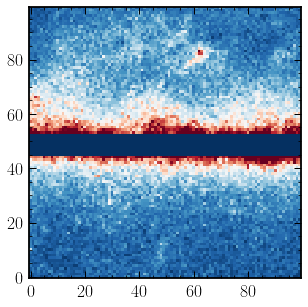

In [117]:
plt.imshow(signal_ensemble[2] * ~mask_roi, vmin=0, vmax=100, origin='lower', cmap=cmap)

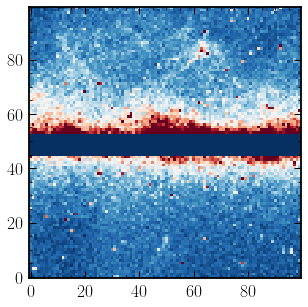

In [118]:
plt.imshow(counts_downsampled * ~mask_roi, vmax=100, cmap=cmap, origin='lower')

In [119]:
np.savez("../data/samples/data_uniform.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)

## Generative model

In [8]:
data = np.load("../data/samples/data_uniform.npz")
signal_ensemble = data["signal_ensemble"]
flux_fraction = data["flux_fraction"]

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping

from models.glow import Glow
from models.glow.module import GlowPL

In [10]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [11]:
x = torch.Tensor(signal_ensemble).unsqueeze(1)
y = torch.Tensor(flux_fraction)

In [12]:
x.max()

tensor(2966.)

In [13]:
x = x[:, :, 2:-2, 2:-2] 

In [14]:
x.shape

torch.Size([30000, 1, 96, 96])

In [32]:
val_fraction = 0.10
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=128, num_workers=0, pin_memory=False, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=128, num_workers=0, pin_memory=False, shuffle=False)

In [15]:
model = GlowPL(num_channels=256, num_levels=5, num_steps=18, quants=x.max() + 1)

In [19]:
model.flow.load_state_dict(torch.load("../data/logs/wandb/run-20220330_045649-45qx9i8l/files/flow.ckpt"))
model.flow.eval();

In [18]:
# checkpoint_callback = ModelCheckpoint(monitor="val_loss")
# lr_monitor = LearningRateMonitor(logging_interval='epoch')

# trainer = pl.Trainer(max_epochs=100, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, lr_monitor])
# trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)

# model.load_from_checkpoint(checkpoint_callback.best_model_path, num_channels=256, num_leveload_state_dict, num_steps=18, quants=x.max() + 1);

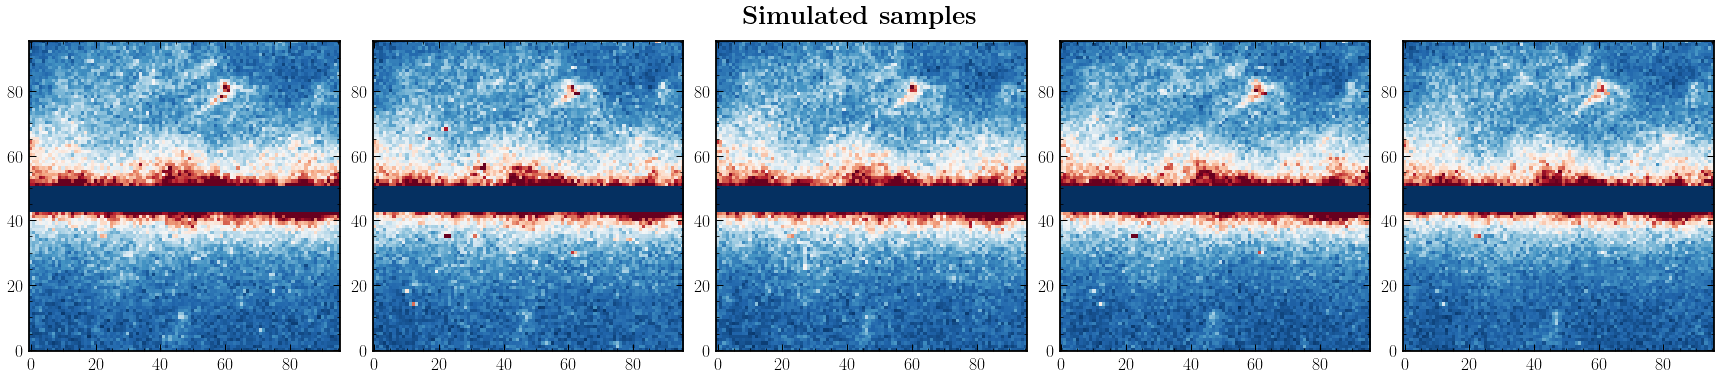

In [74]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2] , cmap=cmap, vmax=100, origin='lower')
    
plt.suptitle(r"\textbf{Simulated samples}", fontsize=26, y=0.9)
plt.tight_layout()

In [20]:
z = torch.randn(size=(5, 1, 96, 96))
x_samples, sldj = model.flow(z, reverse=True)

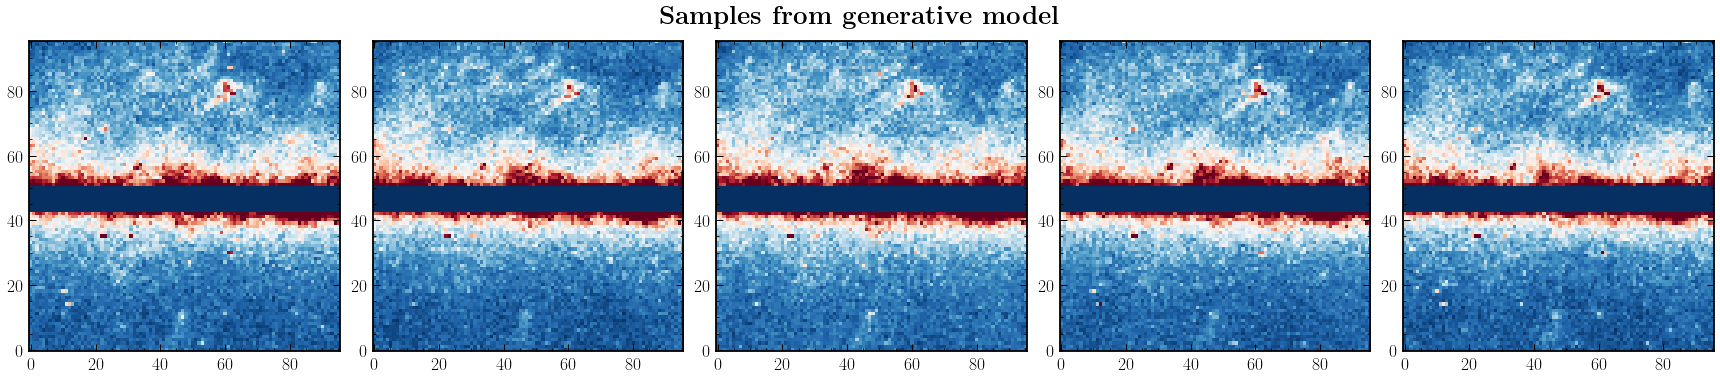

In [26]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmax=100, origin='lower')
    
plt.suptitle(r"\textbf{Samples from generative model}", fontsize=26, y=0.9)
plt.tight_layout()

## Test summaries

In [29]:
from tqdm.notebook import tqdm

In [32]:
x_samples = torch.zeros(500, 1, 96, 96)
for i in tqdm(range(500)):
    z = torch.randn(size=(1, 1, 96, 96))
    x_samples[i, :] = model.flow(z, reverse=True)[0][0]

  0%|          | 0/500 [00:00<?, ?it/s]

In [33]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=128):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

In [34]:
x_pspec_samples = np.array([power_spectrum(x_i) for x_i in x_samples[:, 0, :, :]])
x_pspec_train = np.array([power_spectrum(x_i) for x_i in x[:500, 0]])

x_hist_samples = np.array([counts_histogram(x_i) for x_i in x_samples])
x_hist_train = np.array([counts_histogram(x_i) for x_i in x[:500, 0]])

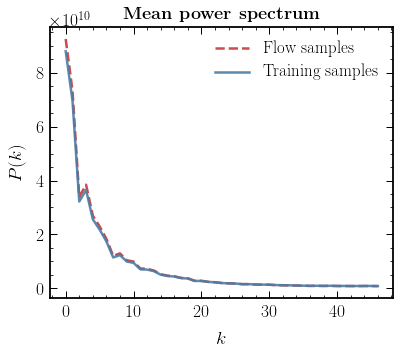

In [35]:
plt.plot(np.nanmean(x_pspec_samples, axis=0)[1:], label="Flow samples", ls='--')
plt.plot(np.mean(x_pspec_train, axis=0)[1:], label="Training samples")

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title(r"\textbf{Mean power spectrum}")
         
plt.legend()

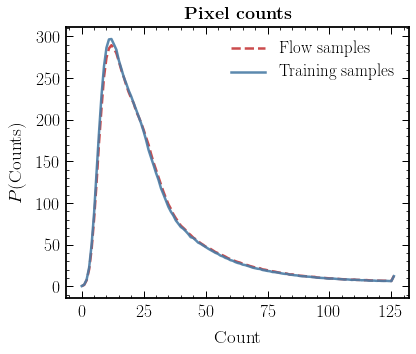

In [36]:
plt.plot(np.nanmean(x_hist_samples, axis=0), label="Flow samples", ls='--')
plt.plot(np.mean(x_hist_train, axis=0), label="Training samples")

plt.xlabel("Count")
plt.ylabel("$P(\mathrm{Counts})$")
plt.title(r"\textbf{Pixel counts}")
         
plt.legend()

In [146]:
from pytorch_wavelets import DWTForward, DWTInverse

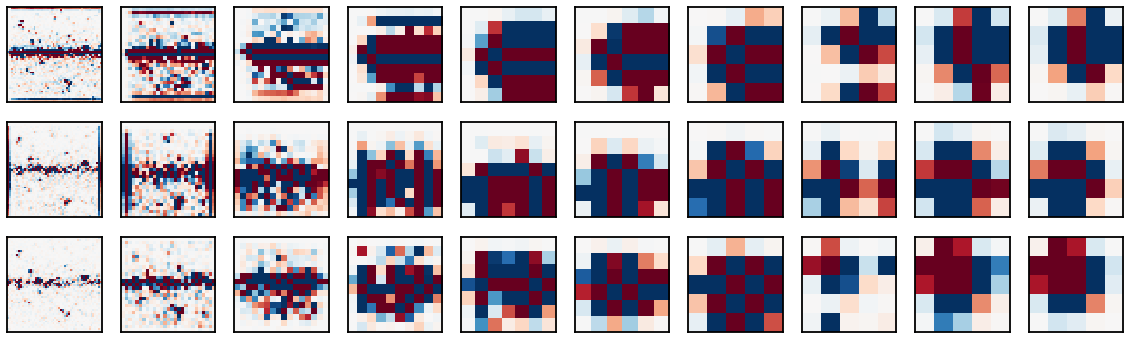

In [164]:
fig, axs = plt.subplots(3, 10, figsize=(20, 6))

xfm = DWTForward(J=10, wave='db3', mode='zero')
Yl, Yh = xfm(x[:500])

for i in range(3):
    for j in range(10):        
        axs[i, j].imshow(Yh[j].mean((0,1))[i], cmap=cmap, vmin=-10, vmax=10)
        axs[i, j].get_xaxis().set_visible(False)
        axs[i, j].get_yaxis().set_visible(False)

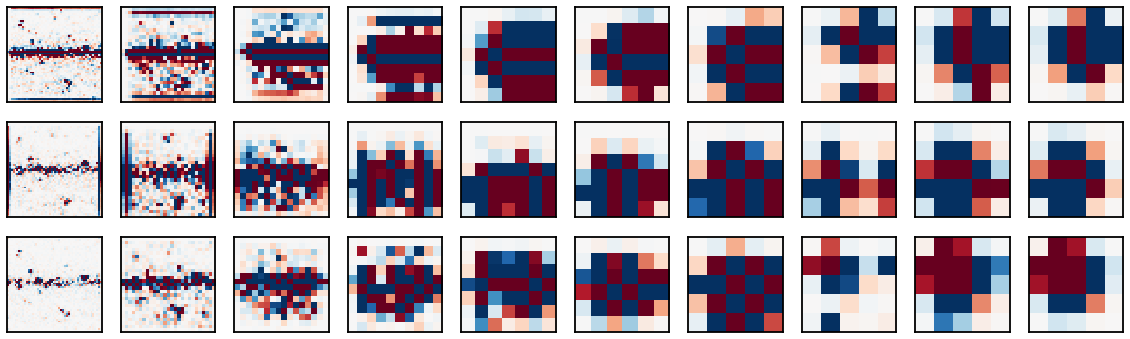

In [165]:
fig, axs = plt.subplots(3, 10, figsize=(20, 6))

xfm = DWTForward(J=10, wave='db3', mode='zero')
Yl, Yh = xfm(x_samples)

for i in range(3):
    for j in range(10):        
        axs[i, j].imshow(Yh[j].mean((0,1))[i], cmap=cmap, vmin=-10, vmax=10)
        axs[i, j].get_xaxis().set_visible(False)
        axs[i, j].get_yaxis().set_visible(False)

## Interpolating in the latent space

In [ ]:
def z_interp(z1, z2, weight=0.5):
    z_interp = torch.lerp(z1, z2, weight)
    return z_interp

In [40]:
z, _ = model.flow(x[5:7])

In [41]:
vrange = 50

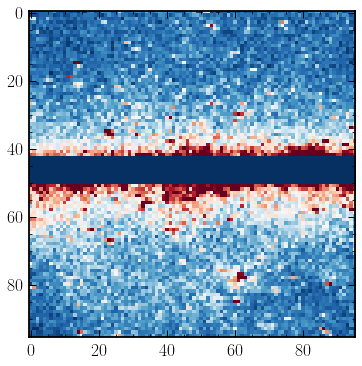

In [42]:
from celluloid import Camera

n_interp = 100

weights_ary = np.linspace(0, 1, n_interp)

fig = plt.figure(figsize=(6,6))

camera = Camera(fig)

for i in range(n_interp):
    
    x_dec = model.flow(z_interp(z[0], z[1], weight=weights_ary[i]).unsqueeze(0), reverse=True)[0]
    
    plt.imshow(x_dec[0,0].detach().numpy() * ~mask_roi, cmap=cmap, vmin=0, vmax=vrange)
    
    camera.snap()

In [43]:
animation = camera.animate()

In [44]:
from IPython.display import HTML
HTML(animation.to_html5_video())

In [45]:
animation.save('latent_interp.gif', fps=15)